Muy muy bueno el código

Librerias

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import zipfile
import io
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score,
                             accuracy_score, roc_curve, roc_auc_score, RocCurveDisplay, make_scorer)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.naive_bayes    import GaussianNB
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
from google.colab import files

# Subir los archivos desde la computadora
uploaded = files.upload()

Saving df_no_respondieron.xlsx to df_no_respondieron.xlsx
Saving df_respondieron.xlsx to df_respondieron.xlsx


In [3]:
for filename, content in uploaded.items():
  # Create a DataFrame for each uploaded file
  df_name = os.path.splitext(filename)[0] # Get the filename without extension
  globals()[df_name] = pd.read_excel(io.BytesIO(content))
  print(f"Created DataFrame: {df_name}")

Created DataFrame: df_no_respondieron
Created DataFrame: df_respondieron


In [4]:
# ------------ 0. Copia de trabajo -------------
base = df_respondieron.copy()

base['ingreso_pc_cero']     = (base['p47t'] == 0).astype(int)
base['ingreso_pc_fam_cero'] = (base['ipcf'] == 0).astype(int)
base['t_vi_cero']           = (base['t_vi'] == 0).astype(int)
base['itf_cero']            = (base['itf'] == 0).astype(int)

# ------------ 1. Filtro de outliers y ceros 1-99 % -------------
def pct_filter(df, col, p_low=1, p_high=99):
    p1, p99 = np.percentile(df[col], [p_low, p_high])
    return df[(df[col] >= p1) & (df[col] <= p99)]

for col in ['p47t', 'ipcf', 'itf', 't_vi']:
    base = pct_filter(base, col)


# ------------ 2. Variables -------------
base['edad']        = base['ch06']
base['edad_sq']     = base['edad']**2

base['log_ingreso_pc'] = np.log1p(base['p47t'])            # 0 -> 0
base['log_ipcf']       = np.log1p(base['ipcf'])
base['log_t_vi']       = np.log1p(base['t_vi'])

base['itf_ratio'] = np.where(base['ipcf'] > 0,
                             base['itf'] / base['ipcf'],
                             0)                            # evita inf
# variables de interacción
base['edu_age_int'] = base['anios_educ'] * base['edad'] # edad x educacion

base['male_single']   = base['ch04_varón'] * base['ch07_soltero']
base['female_single'] = (1 - base['ch04_varón']) * base['ch07_soltero']

# filtrar outliers de la interacción
base = pct_filter(base, 'edu_age_int')

cont_vars = ['edad','edad_sq','log_ingreso_pc','log_ipcf',
             'itf_ratio','edu_age_int','log_t_vi']

# Variables categóricas para los barplots de proporciones
cat_vars  = ['ch04_varón','ch07_soltero',
             'nivel_ed_sin instrucción',
             'ingreso_pc_cero','ingreso_pc_fam_cero',
             'itf_cero','t_vi_cero', 'male_single', 'female_single']


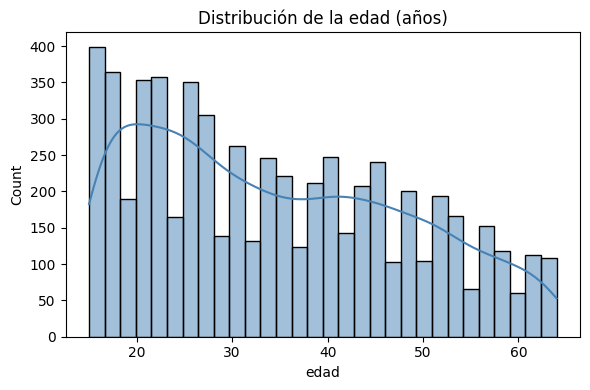

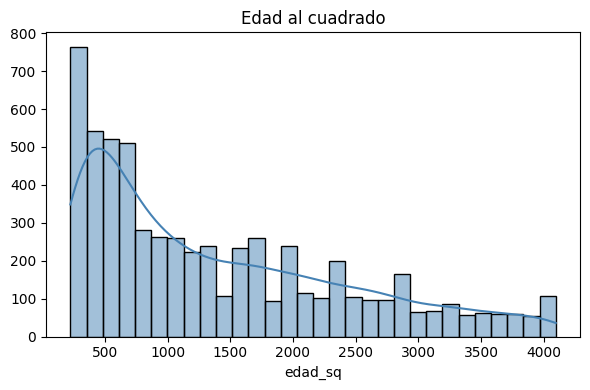

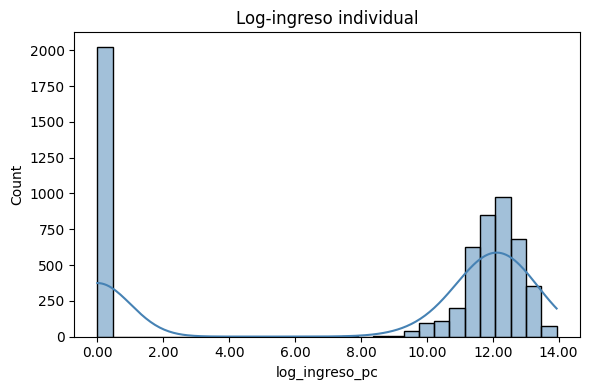

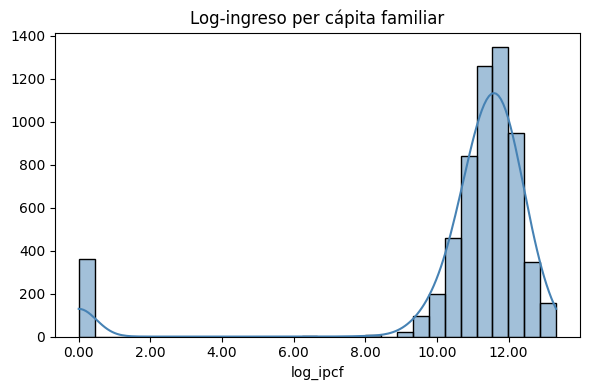

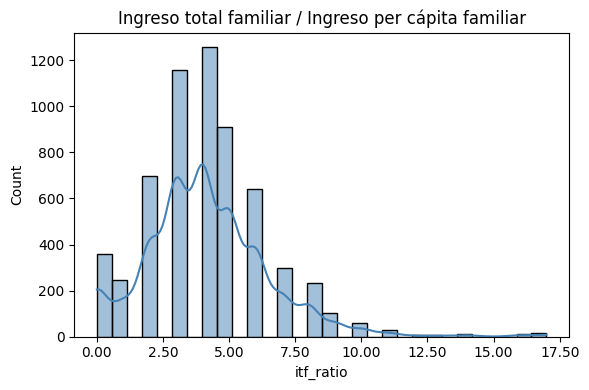

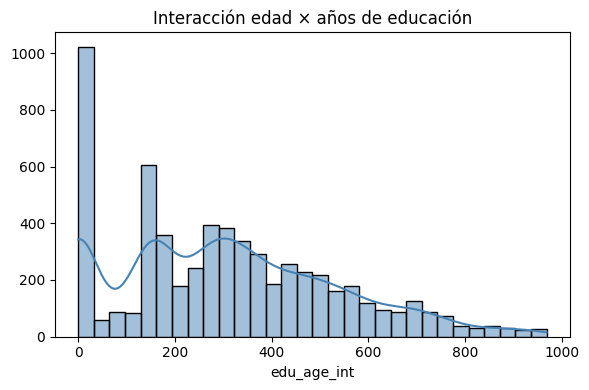

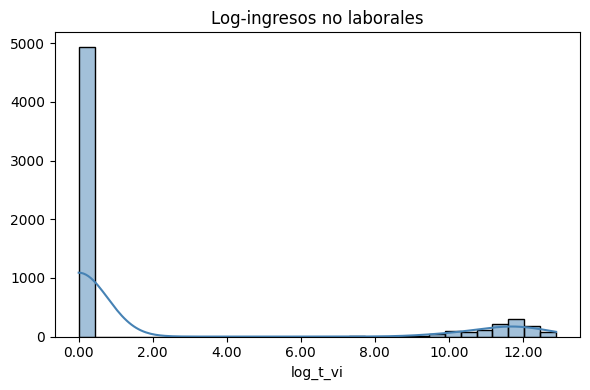

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


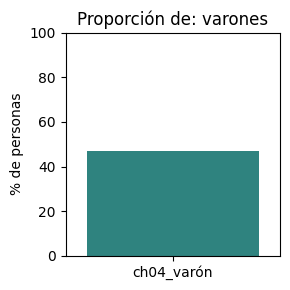

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


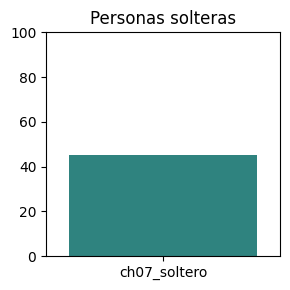

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


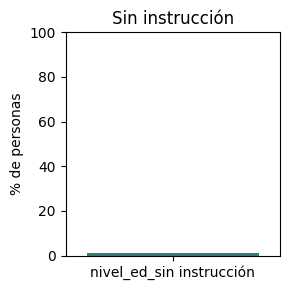

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


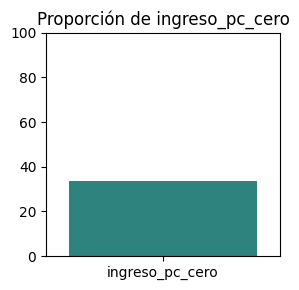

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


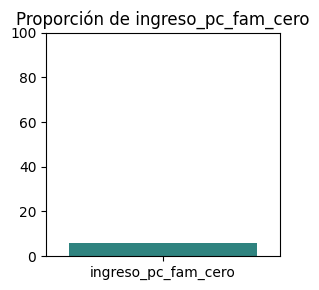

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


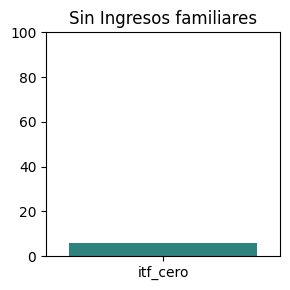

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


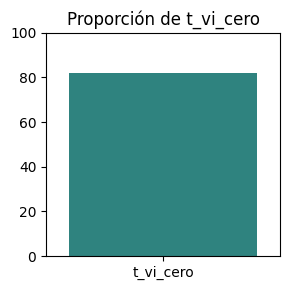

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


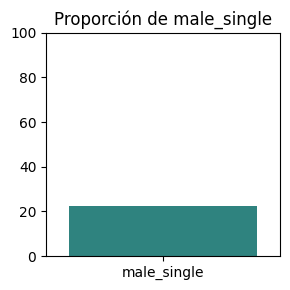

<ipython-input-5-453830306>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)


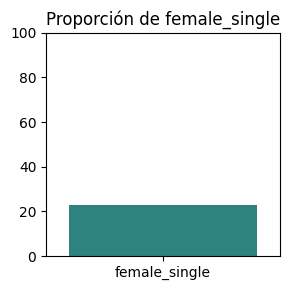

In [5]:
# 1. Diccionarios de títulos
titulos_cont = {
    'edad'             : 'Distribución de la edad (años)',
    'edad_sq'          : 'Edad al cuadrado',
    'log_ingreso_pc'   : 'Log-ingreso individual',
    'log_ipcf'         : 'Log-ingreso per cápita familiar',
    'itf_ratio'        : 'Ingreso total familiar / Ingreso per cápita familiar',
    'edu_age_int'      : 'Interacción edad × años de educación',
    'log_t_vi'         : 'Log-ingresos no laborales',
}

titulos_cat = {
    'ch04_varón'                      : 'Proporción de: varones',
    'ch07_soltero'                    : 'Personas solteras',
    'nivel_ed_sin instrucción'        : 'Sin instrucción',
    'itf_cero'                        : 'Sin Ingresos familiares'}

# variables con etiqueta y
ylabel_cont = {'edad', 'log_ingreso_pc', 'itf_ratio'}
ylabel_cat  = {'ch04_varón', 'nivel_ed_sin instrucción'}

# -------------------------------------------------
# 2. Gráficos continuas
# -------------------------------------------------
for var in cont_vars:
    fig, ax = plt.subplots(figsize=(6,4))
    sns.histplot(base[var], bins=30, kde=True, color='steelblue', ax=ax)

    ax.set_title(titulos_cont.get(var, f'Distribución de {var}'))

    # formateo x-axis
    if var.startswith('log_') or var == 'itf_ratio':
        ax.xaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x,_: f'{x:.2f}'))

    # --- mostrar / quitar eje-Y ---
    if var in ylabel_cont:
        ax.set_ylabel('Count')
    else:
        ax.set_ylabel('')

    plt.tight_layout()
    plt.show()

# -------------------------------------------------
# 3. Gráficos dummies
# -------------------------------------------------
for dummy in cat_vars:
    if dummy in base.columns:
        prop = base[dummy].mean()*100
        fig, ax = plt.subplots(figsize=(3,3))
        sns.barplot(x=[dummy], y=[prop], palette='viridis', ax=ax)

        ax.set_ylim(0, 100)
        ax.set_title(titulos_cat.get(dummy, f'Proporción de {dummy}'))

        # --- mostrar / quitar eje-Y ---
        if dummy in ylabel_cat:
            ax.set_ylabel('% de personas')
        else:
            ax.set_ylabel('')

        plt.tight_layout()
        plt.show()

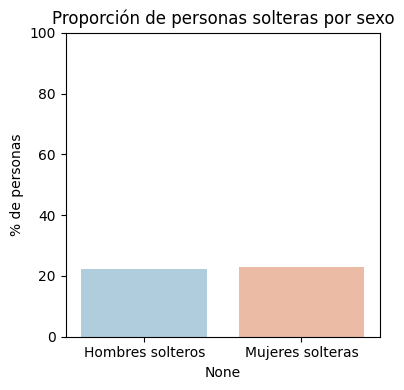

In [6]:
# --- calcular proporciones (%) ---
props = (base[['male_single', 'female_single']].mean()*100)

# --- gráfico comparativo ---
plt.figure(figsize=(4,4))
sns.barplot(x=props.index, y=props.values, hue=props.index, palette='RdBu_r', legend=False)
plt.ylim(0,100)
plt.ylabel('% de personas')
plt.title('Proporción de personas solteras por sexo')
plt.xticks(ticks=[0, 1], labels=['Hombres solteros', 'Mujeres solteras'])
plt.tight_layout()
plt.show()

In [7]:
# Como la proporción es muy baja para algunas variables categóricas las eliminamos

cat_vars  = ['ch04_varón','ch07_soltero', 'nivel_ed_sin instrucción',
             'ingreso_pc_cero','ingreso_pc_fam_cero',
             'itf_cero','t_vi_cero', 'female_single']

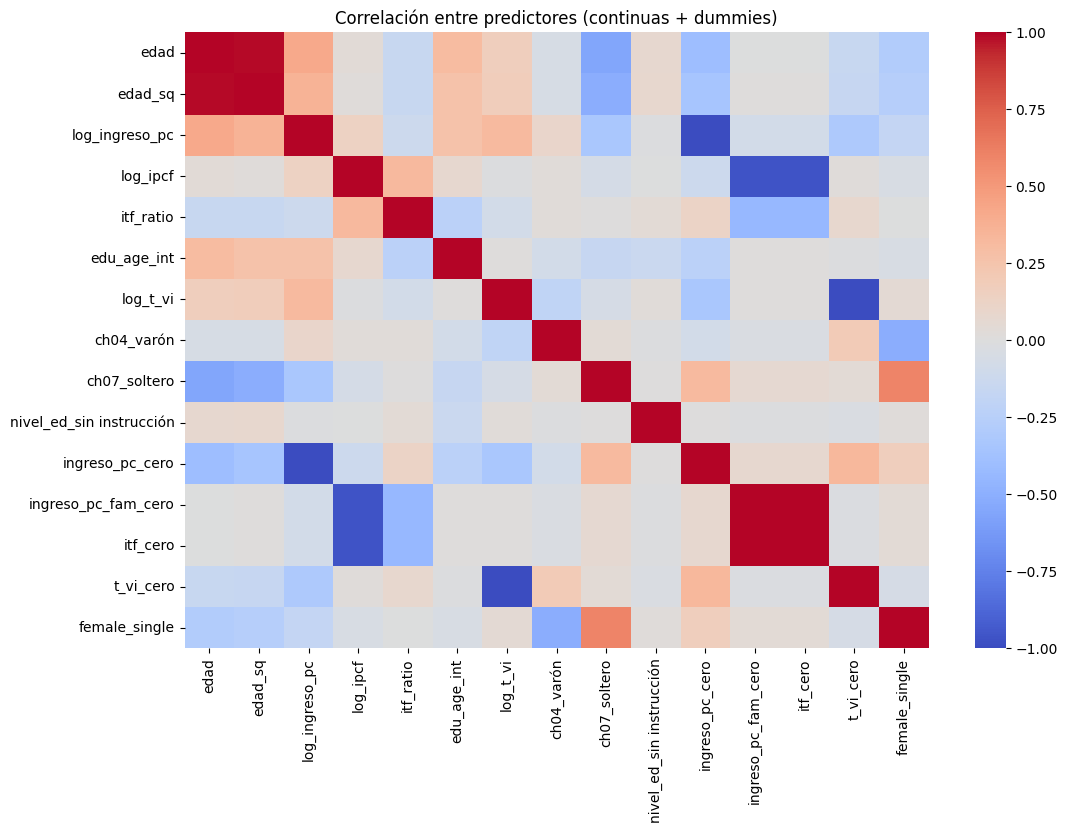

                    variable         VIF
12                  itf_cero         inf
11       ingreso_pc_fam_cero         inf
10           ingreso_pc_cero  178.673230
2             log_ingreso_pc  123.682301
13                 t_vi_cero   69.144352
0                       edad   52.125428
1                    edad_sq   46.143522
3                   log_ipcf   24.641488
6                   log_t_vi   12.533894
8               ch07_soltero    5.657117
7                 ch04_varón    4.006374
14             female_single    3.922577
4                  itf_ratio    1.643450
5                edu_age_int    1.383031
9   nivel_ed_sin instrucción    1.052631


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [8]:
# Matriz de correlaicones y VIF
# --- Selección de columnas numéricas que entran al modelo ---
# 1. Construimos X
X = base[cont_vars + cat_vars].copy()

# 2. Escalar solo continuas
X[cont_vars] = StandardScaler().fit_transform(X[cont_vars])

# 3. Asegurar que TODOS los cat_vars sean numéricos (0/1) y float
X[cat_vars] = X[cat_vars].astype(float)          # de bool/int → float

# 4. Eliminar columnas que quedaron constantes (var = 0) — evitan VIF infinito
const_cols = [c for c in X.columns if X[c].var() == 0]
if const_cols:
    print("Columnas constantes eliminadas:", const_cols)
    X = X.drop(columns=const_cols)

# 5. Eliminar filas con NaN/inf que pudieran haber quedado
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# ------------------ MATRIZ DE CORRELACIONES ------------------
corr = X.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre predictores (continuas + dummies)')
plt.show()

# ------------------ VIF ------------------
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif.head(15))

In [9]:
# Features finales:
cat_vars  = ['ch04_varón','ch07_soltero','nivel_ed_sin instrucción','itf_cero', 'female_single']

cont_vars = ['edad','edad_sq','log_ingreso_pc',
             'itf_ratio','edu_age_int','log_t_vi']

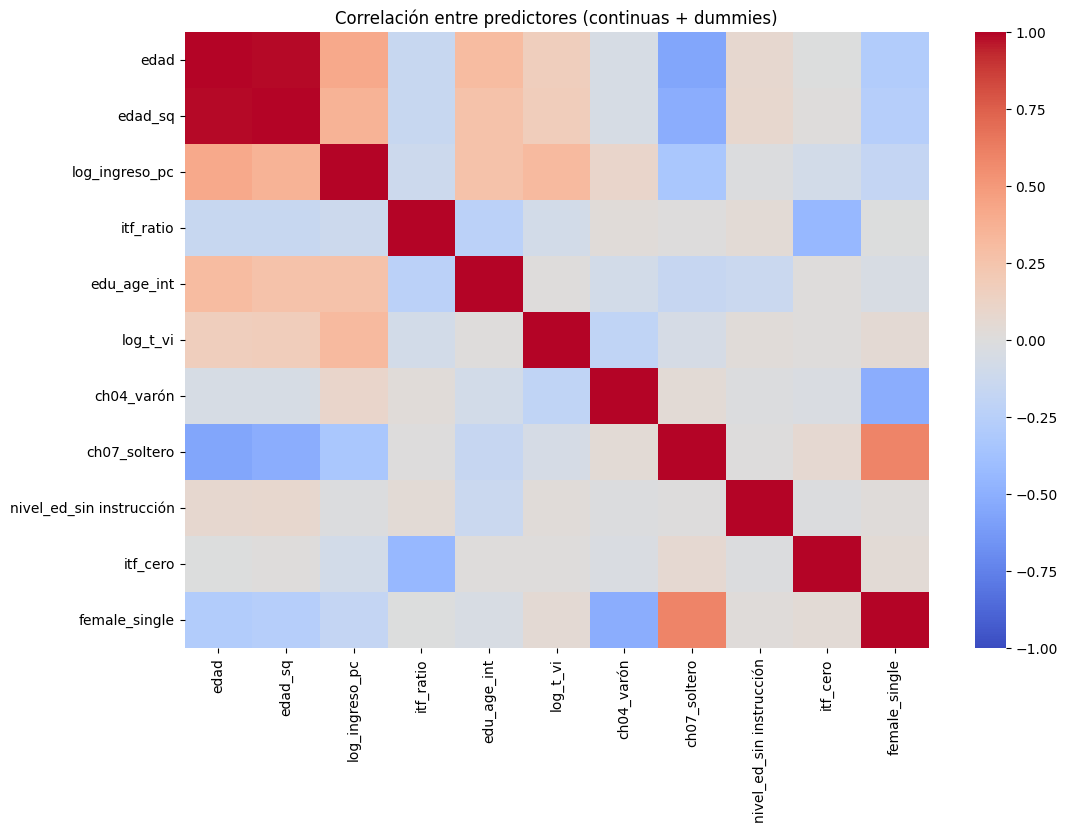

                    variable        VIF
0                       edad  48.526204
1                    edad_sq  43.937910
7               ch07_soltero   5.317901
10             female_single   3.208636
6                 ch04_varón   2.370349
2             log_ingreso_pc   1.648839
3                  itf_ratio   1.352172
9                   itf_cero   1.337808
4                edu_age_int   1.283936
5                   log_t_vi   1.238505
8   nivel_ed_sin instrucción   1.052019


In [10]:
# Matriz de correlaicones y VIF
# --- Selección de columnas numéricas que entran al modelo ---
# 1. Construimos X
X = base[cont_vars + cat_vars].copy()

# 2. Escalar solo continuas
X[cont_vars] = StandardScaler().fit_transform(X[cont_vars])

# 3. Asegurar que TODOS los cat_vars sean numéricos (0/1) y float
X[cat_vars] = X[cat_vars].astype(float)          # de bool/int → float

# 4. Eliminar columnas que quedaron constantes (var = 0) — evitan VIF infinito
const_cols = [c for c in X.columns if X[c].var() == 0]
if const_cols:
    print("Columnas constantes eliminadas:", const_cols)
    X = X.drop(columns=const_cols)

# 5. Eliminar filas con NaN/inf que pudieran haber quedado
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# ------------------ MATRIZ DE CORRELACIONES ------------------
corr = X.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre predictores (continuas + dummies)')
plt.show()

# ------------------ VIF ------------------
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif.head(15))

In [11]:
# Split año por año con random_state=444
def split_by_year(df, year, Xcols, ycol='desocupado'):
    df_y = df[df['ano4'] == year].copy()
    X, y = df_y[Xcols], df_y[ycol]
    return train_test_split(X, y, test_size=0.30,
                            random_state=444, stratify=y)

Xcols = cont_vars + cat_vars            # todas las features

X_train04, X_test04, y_train04, y_test04 = split_by_year(base, 2004, Xcols)
X_train24, X_test24, y_train24, y_test24 = split_by_year(base, 2024, Xcols)

# Columna de 1s
for Xset in [X_train04, X_test04, X_train24, X_test24]:
    Xset['const'] = 1.0

In [12]:
# Diferencia de medias
def diff_means(Xtr, Xte):
    tab = pd.DataFrame({'train_mean': Xtr.mean(),
                        'test_mean':  Xte.mean()})
    tab['diff'] = tab['train_mean'] - tab['test_mean']
    return tab.round(3)

print("\n Diferencia de medias 2004")
display(diff_means(X_train04[cont_vars], X_test04[cont_vars]))

print("\n Diferencia de medias 2024")
display(diff_means(X_train24[cont_vars], X_test24[cont_vars]))


 Diferencia de medias 2004


,train_mean,test_mean,diff
edad,33.092,33.590,-0.498
edad_sq,1277.910,1313.308,-35.398
log_ingreso_pc,6.990,7.097,-0.106
itf_ratio,4.899,4.921,-0.022
edu_age_int,252.848,254.865,-2.017
log_t_vi,1.318,1.226,0.092



 Diferencia de medias 2024


,train_mean,test_mean,diff
edad,35.951,36.172,-0.221
edad_sq,1478.782,1499.487,-20.705
log_ingreso_pc,9.042,9.127,-0.085
itf_ratio,3.338,3.242,0.096
edu_age_int,363.293,368.932,-5.639
log_t_vi,2.958,2.914,0.044


In [13]:
# Estandarización SOLO de continuas

### COMENTARIO TOMI: muy bueno

pre = ColumnTransformer(
        [('num', StandardScaler(), cont_vars)],
        remainder='passthrough')        # dummies y “const” se dejan igual

# Métricas:
def metrics_from_confmat(cm):
    vn, fp, fn, vp = cm.ravel()
    P, N, T = vp+fn, vn+fp, vn+fp+vp+fn
    return {
        'TPR (sens)':   vp / P if P else 0,
        'FPR':          fp / N if N else 0,
        'Accuracy':    (vp+vn) / T,
        'Specificity':  vn / N if N else 0,
        'Precision':          vp / (vp+fp) if (vp+fp) else 0,
        'VPN':          vn / (vn+fn) if (vn+fn) else 0
    }
# Clasificadores:
models = {
    'Logit' : LogisticRegression(max_iter=500, solver='lbfgs'),
    'LDA'   : LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'QDA'   : QuadraticDiscriminantAnalysis(reg_param=0.01),
    'KNN-5' : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}


================  2004  ================


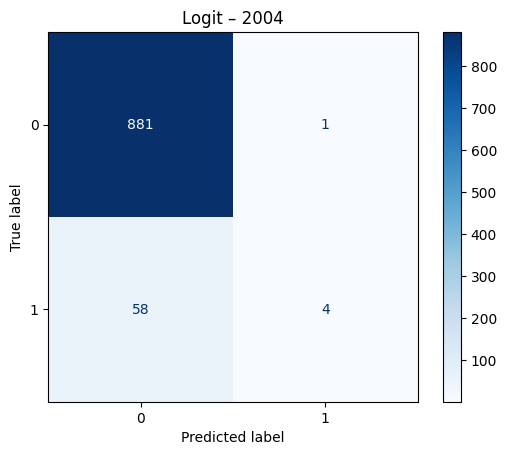

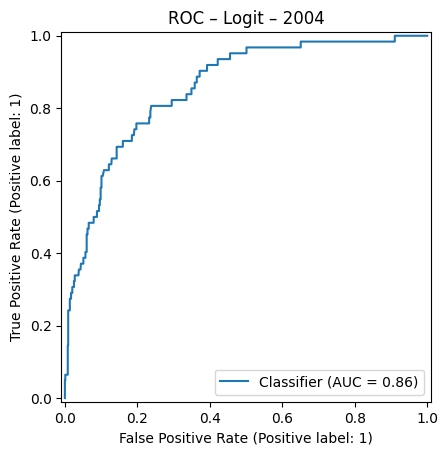

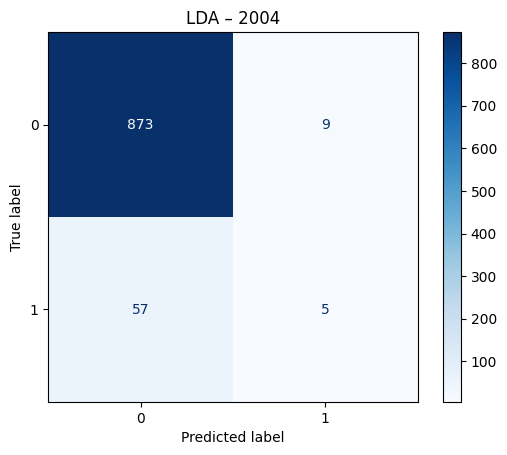

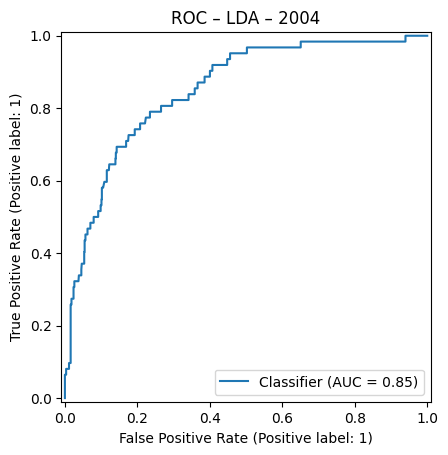

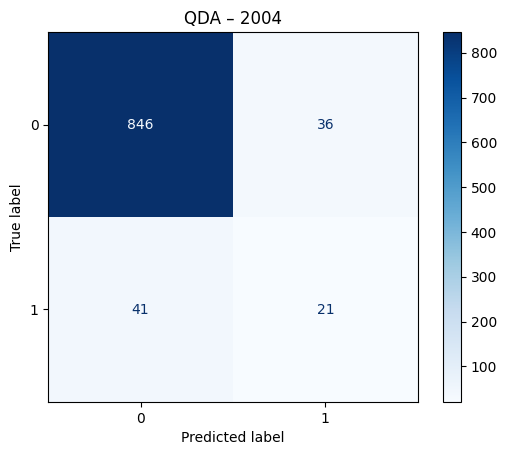

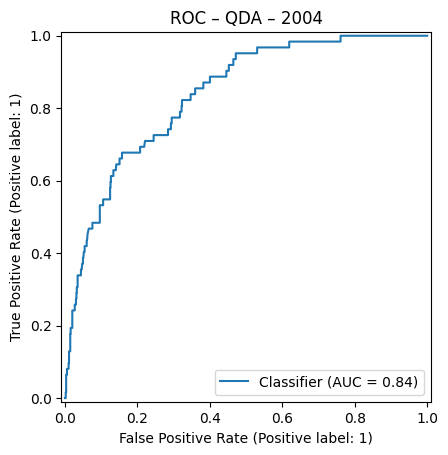

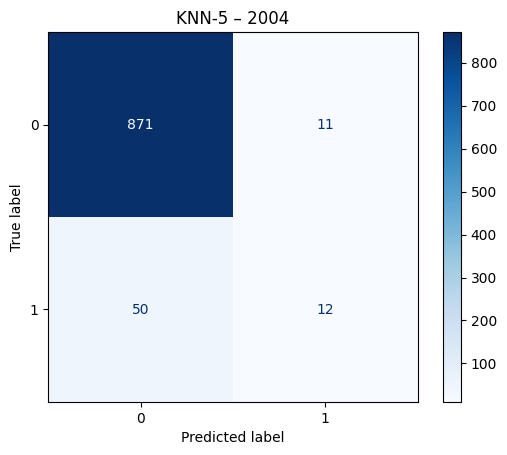

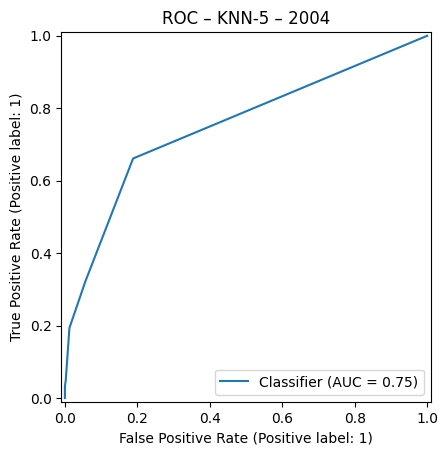

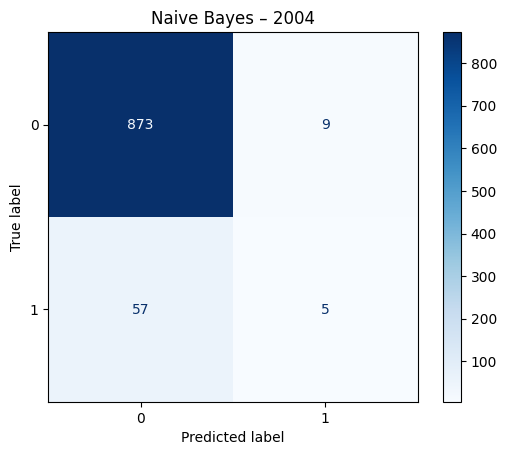

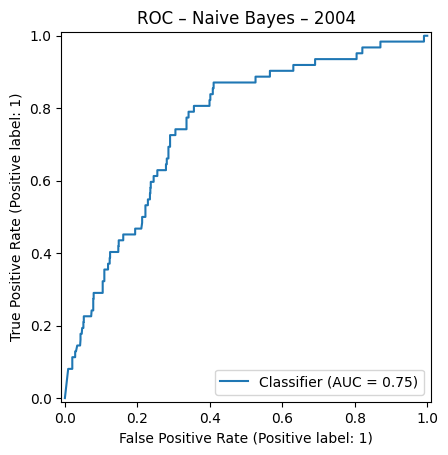


================  2024  ================


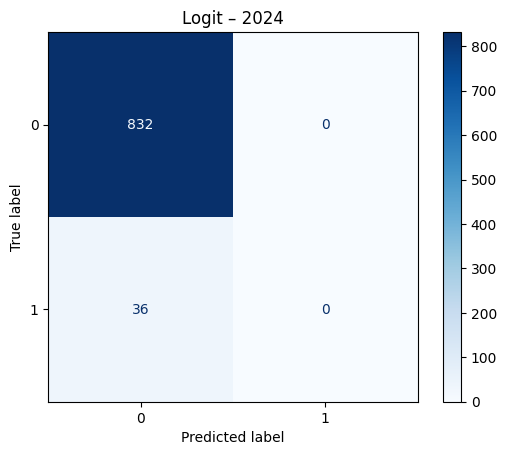

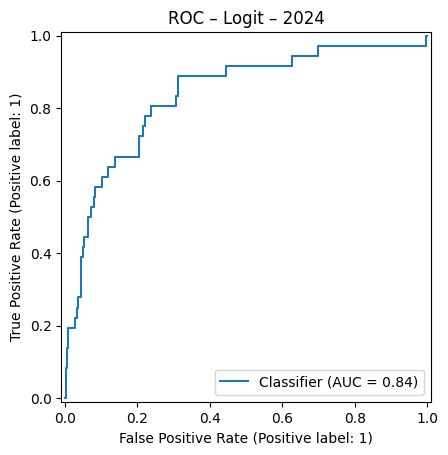

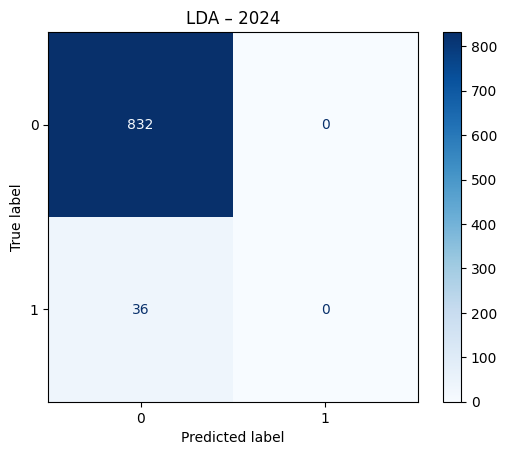

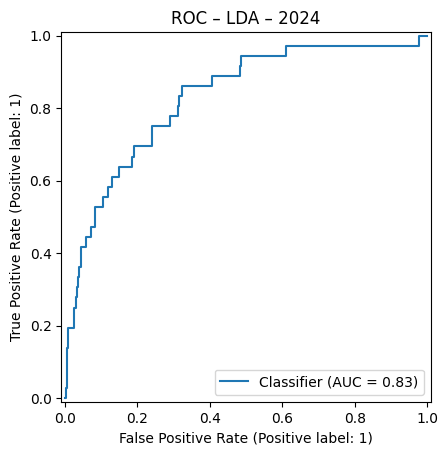

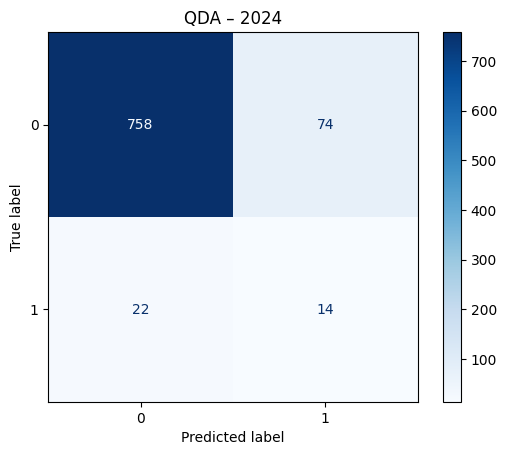

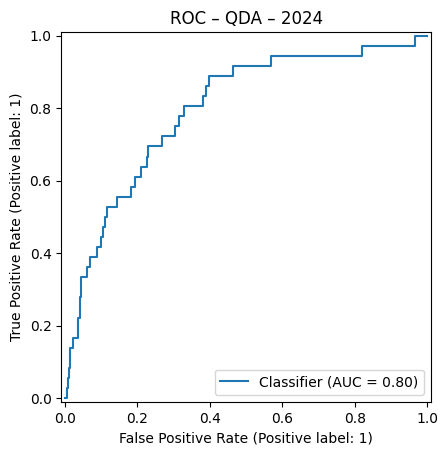

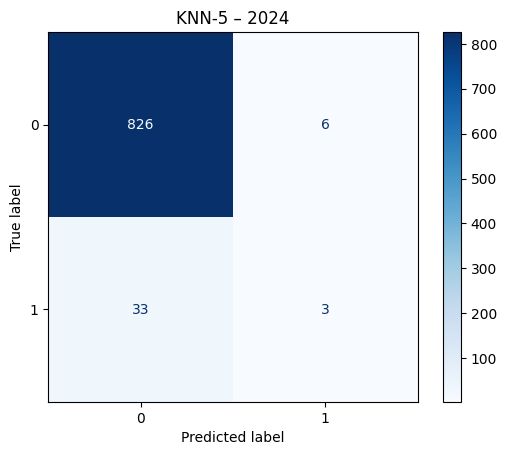

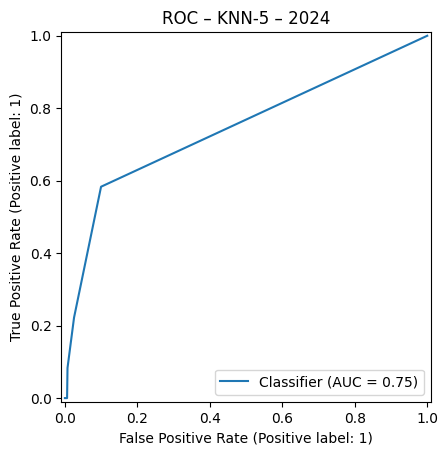

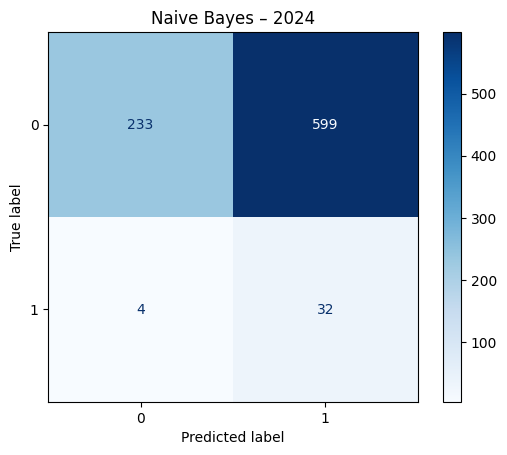

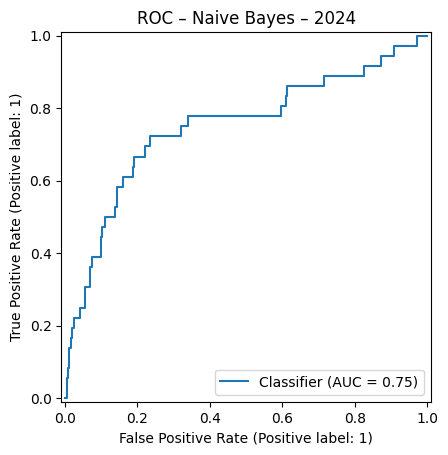

TPR (sens)    FPR  Accuracy  Specificity  Precision    VPN  \
Modelo      Año                                                                
KNN-5       2004       0.194  0.012     0.935        0.988      0.522  0.946   
            2024       0.083  0.007     0.955        0.993      0.333  0.962   
LDA         2004       0.081  0.010     0.930        0.990      0.357  0.939   
            2024       0.000  0.000     0.959        1.000      0.000  0.959   
Logit       2004       0.065  0.001     0.938        0.999      0.800  0.938   
            2024       0.000  0.000     0.959        1.000      0.000  0.959   
Naive Bayes 2004       0.081  0.010     0.930        0.990      0.357  0.939   
            2024       0.889  0.720     0.305        0.280      0.051  0.983   
QDA         2004       0.339  0.041     0.918        0.959      0.368  0.954   
            2024       0.389  0.089     0.889        0.911      0.159  0.972   

                    AUC  
Modelo      Año          
KNN-5       2004  0.752  
            2024  0.746  
LDA         2004  0.850  
            2024  0.828  
Logit       2004  0.856  
            2024  0.835  
Naive Bayes 2004  0.753  
            2024  0.748  
QDA         2004  0.837  
            2024  0.796

In [ ]:
results = []   # guardaremos dicts

for yr, (Xt, Xv, yt, yv) in zip([2004, 2024],
        [(X_train04,X_test04,y_train04,y_test04),
         (X_train24,X_test24,y_train24,y_test24)]):

    print(f"\n================  {yr}  ================")
    for name, mdl in models.items():
        pipe = Pipeline([('pre', pre), ('mod', mdl)])
        pipe.fit(Xt, yt)

        y_pred = pipe.predict(Xv)
        y_prob = (pipe.predict_proba(Xv)[:,1]
                  if hasattr(pipe,'predict_proba') else None)

        cm = confusion_matrix(yv, y_pred)
        m  = metrics_from_confmat(cm)
        m['AUC']      = roc_auc_score(yv, y_prob) if y_prob is not None else np.nan
        m['Modelo']   = name
        m['Año']      = yr
        results.append(m)

        # matriz + ROC opcional:
        ConfusionMatrixDisplay(cm).plot(cmap='Blues')
        plt.title(f"{name} – {yr}")
        plt.show()

        if y_prob is not None:
            RocCurveDisplay.from_predictions(yv, y_prob)
            plt.title(f"ROC – {name} – {yr}")
            plt.show()

# ---------------- Tabla final -----------------
metrics_df = (pd.DataFrame(results)
              .set_index(['Modelo','Año'])
              .round(3)
              .sort_index())
display(metrics_df)


In [ ]:
# Cross validation:

# ---------- diccionario de scorers ----------
scorers = {
    'accuracy'   : make_scorer(accuracy_score),
    'precision'  : make_scorer(precision_score,  pos_label=1, zero_division=0),
    'tpr'        : make_scorer(recall_score,      pos_label=1),     # sensibilidad
    'fpr'        : make_scorer(recall_score,      pos_label=0,
                               greater_is_better=False),
    'specificity': make_scorer(recall_score,      pos_label=0),
    'vpn'        : make_scorer(precision_score,   pos_label=0, zero_division=0),
    'auc'        : 'roc_auc'
}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=444)

def cv_por_año(df, año, modelo, Xcols, ycol='desocupado', k=5):
    subset = df[df['ano4'] == año].copy()
    X = subset[Xcols]
    y = subset[ycol]

    # estandarizamos solo las continuas
    cont = [c for c in Xcols if X[c].dtype != 'uint8' and X[c].nunique()>10]
    prepro = ColumnTransformer(
        [('std', StandardScaler(), cont)],
        remainder='passthrough', verbose_feature_names_out=False
    )

    pipe = Pipeline(steps=[('prep', prepro), ('clf', modelo)])

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=444)

    res = cross_validate(
        pipe, X, y, cv=cv, scoring=scorers, return_train_score=False
    )
    # promedio de cada métrica
    return {m: res[f'test_{m}'].mean() for m in scorers.keys()}

# Ejecutar CV y recopilar resultados
# ------------------------------------------------------------------
tabla = []
for nombre, mdl in models.items():
    for yr in [2004, 2024]:
        met = cv_por_año(base, yr, mdl, Xcols)
        met.update({'Modelo': nombre, 'Año': yr})
        tabla.append(met)

resultados = pd.DataFrame(tabla)
print(resultados.round(3))


   accuracy  precision    tpr    fpr  specificity    vpn    auc       Modelo  \
0     0.933      0.350  0.029 -0.997        0.997  0.935  0.861        Logit   
1     0.958      0.000  0.000 -1.000        1.000  0.958  0.858        Logit   
2     0.930      0.319  0.043 -0.993        0.993  0.936  0.852          LDA   
3     0.959      0.400  0.017 -1.000        1.000  0.959  0.843          LDA   
4     0.921      0.370  0.250 -0.968        0.968  0.948  0.837          QDA   
5     0.897      0.199  0.467 -0.915        0.915  0.975  0.841          QDA   
6     0.930      0.441  0.139 -0.986        0.986  0.942  0.716        KNN-5   
7     0.952      0.221  0.058 -0.991        0.991  0.960  0.744        KNN-5   
8     0.930      0.277  0.062 -0.991        0.991  0.937  0.743  Naive Bayes   
9     0.265      0.051  0.958 -0.235        0.235  0.993  0.766  Naive Bayes   

    Año  
0  2004  
1  2024  
2  2004  
3  2024  
4  2004  
5  2024  
6  2004  
7  2024  
8  2004  
9  2024  


In [ ]:
# Tabla de resultados
# 1. redondeamos para mostrar
res_round = resultados.round(3)

# 2. ordenamos por Año y luego por AUC (descendente)
ordenado = (res_round
            .sort_values(['Año', 'auc'], ascending=[True, False])
            .reset_index(drop=True))

display(ordenado)

,accuracy,precision,tpr,fpr,specificity,vpn,auc,Modelo,Año
0,0.933,0.350,0.029,-0.997,0.997,0.935,0.861,Logit,2004
1,0.930,0.319,0.043,-0.993,0.993,0.936,0.852,LDA,2004
2,0.921,0.370,0.250,-0.968,0.968,0.948,0.837,QDA,2004
3,0.930,0.277,0.062,-0.991,0.991,0.937,0.743,Naive Bayes,2004
4,0.930,0.441,0.139,-0.986,0.986,0.942,0.716,KNN-5,2004
5,0.958,0.000,0.000,-1.000,1.000,0.958,0.858,Logit,2024
6,0.959,0.400,0.017,-1.000,1.000,0.959,0.843,LDA,2024
7,0.897,0.199,0.467,-0.915,0.915,0.975,0.841,QDA,2024
8,0.265,0.051,0.958,-0.235,0.235,0.993,0.766,Naive Bayes,2024
9,0.952,0.221,0.058,-0.991,0.991,0.960,0.744,KNN-5,2024


In [ ]:
# Tabla por año
for yr in [2004, 2024]:
    print(f"\n=== Resultados {yr} (ordenados por AUC) ===")
    display(ordenado[ordenado['Año'] == yr]
            .sort_values('auc', ascending=False)
            .set_index('Modelo'))


=== Resultados 2004 (ordenados por AUC) ===


,accuracy,precision,tpr,fpr,specificity,vpn,auc,Año
Modelo,,,,,,,,
Logit,0.933,0.350,0.029,-0.997,0.997,0.935,0.861,2004
LDA,0.930,0.319,0.043,-0.993,0.993,0.936,0.852,2004
QDA,0.921,0.370,0.250,-0.968,0.968,0.948,0.837,2004
Naive Bayes,0.930,0.277,0.062,-0.991,0.991,0.937,0.743,2004
KNN-5,0.930,0.441,0.139,-0.986,0.986,0.942,0.716,2004



=== Resultados 2024 (ordenados por AUC) ===


,accuracy,precision,tpr,fpr,specificity,vpn,auc,Año
Modelo,,,,,,,,
Logit,0.958,0.000,0.000,-1.000,1.000,0.958,0.858,2024
LDA,0.959,0.400,0.017,-1.000,1.000,0.959,0.843,2024
QDA,0.897,0.199,0.467,-0.915,0.915,0.975,0.841,2024
Naive Bayes,0.265,0.051,0.958,-0.235,0.235,0.993,0.766,2024
KNN-5,0.952,0.221,0.058,-0.991,0.991,0.960,0.744,2024


In [ ]:
# No respondieron
print(df_no_respondieron.shape)

# Con solo 6 observaciones no tiene sentido realizar el modelo!

(6, 67)
